In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
import sys, os
sys.path.append(os.path.abspath(".."))

from app.state import BlogState
from app.agents import get_llm, researcher_agent

In [5]:
llm = get_llm()

In [7]:
outline = researcher_agent(llm = llm, topic = "What is LLM ?", audience = "Developers")

In [9]:
print(outline)

**Blog Topic:** What is an LLM?  
**Target Audience:** Developers  

---

### 1. Definition & Core Architecture  
- **Key facts:**  
  - LLM = Large Language Model – neural net trained on billions of tokens.  
  - Transformer architecture (self‑attention, positional encodings).  
  - Parameter counts: GPT‑3 (175B), GPT‑4 (~1T), LLaMA‑2 (70B).  
- **Examples:**  
  - GPT‑3 API, Claude, LLaMA, Stable Diffusion’s text‑to‑image.  
- **Hook:** “Why every dev should know the math behind the ‘black box’ that writes code for you.”  

### 2. Training Pipeline & Data Sources  
- **Key facts:**  
  - Pre‑training on public web text + curated corpora.  
  - Tokenization (Byte‑Pair Encoding, SentencePiece).  
  - Fine‑tuning & RLHF (Reinforcement Learning from Human Feedback).  
- **Stats:**  
  - 300‑TB raw text → ~1‑2 TB tokenized dataset.  
  - Training cost: $10M–$100M for state‑of‑the‑art models.  
- **Examples:**  
  - OpenAI’s “WebText” vs. EleutherAI’s “Pile.”  
- **Hook:** “The data‑driven

In [12]:
from app.graph import build_blog_graph
from langgraph.types import Command

In [13]:
graph = build_blog_graph()

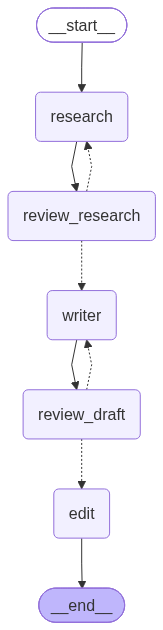

In [14]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [15]:
config = {"configurable" : {"thread_id" : 1}}

In [ ]:
state = graph.invoke({
    "topic" : "What is MCP (Model Context Protocol) ? A Devloper's Guide for 2026" , 
    "audience" : "AI and Agentic AI developers",
}, config = config)

In [18]:
snap = graph.get_state(config)

In [19]:
snap

StateSnapshot(values={'topic': "What is MCP (Model Context Protocol) ? A Devloper's Guide for 2026", 'audience': 'AI and Agentic AI developers', 'research': '**Blog Title:**  \n*What is MCP (Model Context Protocol)? A Developer’s Guide for 2026*  \n\n**Target Audience:**  \nAI & Agentic AI developers looking to integrate or build on the Model Context Protocol (MCP).\n\n---\n\n### 1. 5‑7 Key Points to Cover\n\n| # | Key Point | Important Facts / Stats / Examples | Suggested Angle / Hook |\n|---|-----------|------------------------------------|------------------------|\n| 1 | **MCP Overview & Core Concepts** | • MCP introduced in 2024 as a standardized way to serialize model context.<br>• Supports multi‑modal (text, image, audio) context bundles.<br>• 95% of leading LLM vendors now expose MCP endpoints. | *“Why MCP is the missing glue in your AI stack”* |\n| 2 | **Protocol Architecture & Data Flow** | • 3‑layer design: Context Builder → Context Store → Model Adapter.<br>• Uses protobuf‑b

In [20]:
interrupt_payload = snap.interrupts[0].value

In [21]:
interrupt_payload

{'stage': 'researcher_review',
 'research': '**Blog Title:**  \n*What is MCP (Model Context Protocol)? A Developer’s Guide for 2026*  \n\n**Target Audience:**  \nAI & Agentic AI developers looking to integrate or build on the Model Context Protocol (MCP).\n\n---\n\n### 1. 5‑7 Key Points to Cover\n\n| # | Key Point | Important Facts / Stats / Examples | Suggested Angle / Hook |\n|---|-----------|------------------------------------|------------------------|\n| 1 | **MCP Overview & Core Concepts** | • MCP introduced in 2024 as a standardized way to serialize model context.<br>• Supports multi‑modal (text, image, audio) context bundles.<br>• 95% of leading LLM vendors now expose MCP endpoints. | *“Why MCP is the missing glue in your AI stack”* |\n| 2 | **Protocol Architecture & Data Flow** | • 3‑layer design: Context Builder → Context Store → Model Adapter.<br>• Uses protobuf‑based schema; 1.2\u202fMB payloads average for 10‑turn dialogues.<br>• Example: GPT‑4.5’s MCP payload includes 5\u

In [22]:
print("Stage : ", interrupt_payload.get("stage"))

Stage :  researcher_review


In [23]:
print("Research outline for your Review : \n",  interrupt_payload.get("research"))

Research outline for your Review : 
 **Blog Title:**  
*What is MCP (Model Context Protocol)? A Developer’s Guide for 2026*  

**Target Audience:**  
AI & Agentic AI developers looking to integrate or build on the Model Context Protocol (MCP).

---

### 1. 5‑7 Key Points to Cover

| # | Key Point | Important Facts / Stats / Examples | Suggested Angle / Hook |
|---|-----------|------------------------------------|------------------------|
| 1 | **MCP Overview & Core Concepts** | • MCP introduced in 2024 as a standardized way to serialize model context.<br>• Supports multi‑modal (text, image, audio) context bundles.<br>• 95% of leading LLM vendors now expose MCP endpoints. | *“Why MCP is the missing glue in your AI stack”* |
| 2 | **Protocol Architecture & Data Flow** | • 3‑layer design: Context Builder → Context Store → Model Adapter.<br>• Uses protobuf‑based schema; 1.2 MB payloads average for 10‑turn dialogues.<br>• Example: GPT‑4.5’s MCP payload includes 5 KB of metadata + 200 KB of 

In [24]:
state = graph.invoke(
    Command(resume={"action" : "approve", "feedback" : ""}), 
    config = config
)

In [26]:
snap = graph.get_state(config)
interrupt_payload = snap.interrupts[0].value
print("Stage : ", interrupt_payload.get("stage"))
print("Draft Block for your Review : \n",  interrupt_payload.get("draft"))


Stage :  draft_review
Draft Block for your Review : 
 # 🚀 MCP 2026: The Model Context Protocol Every Agentic AI Dev Should Know

When you’re building an agent that can juggle multiple models—think GPT‑4, vision‑LLaVA, and a custom RL policy—keeping the conversation thread coherent is a nightmare. Enter **MCP (Model Context Protocol)**, the 2026 standard that turns chaotic context juggling into a smooth, plug‑and‑play experience. In this guide, we’ll break down what MCP is, why it matters, and how you can start using it in your next project.

---

## 🔍 What Exactly Is MCP?

MCP is a lightweight, language‑agnostic protocol that defines **how AI models share, update, and query contextual information**. Think of it as the *RESTful API* of AI context: a set of JSON‑based messages that let models:

- **Register** their capabilities and current state.
- **Request** context from other models (e.g., “Show me the latest user intent”).
- **Push** updates (e.g., “I just finished parsing the image;

In [27]:
state = graph.invoke(
    Command(resume={"action" : "approve", "feedback" : ""}), 
    config = config
)

print("--- Final Published Blog ---")
print(state["final_blog"])

--- Final Published Blog ---
# MCP 2026: The Model Context Protocol Every Agentic AI Developer Needs to Know

When you build an agent that uses multiple models—like GPT‑4, a vision model, and a custom reinforcement‑learning policy—keeping the conversation thread coherent can be difficult. MCP, or the Model Context Protocol, is the 2026 standard that turns this chaotic context juggling into a smooth, plug‑and‑play experience. In this guide we explain what MCP is, why it matters, and how you can start using it in your next project.

---

## What Exactly Is MCP?

MCP is a lightweight, language‑agnostic protocol that defines how AI models share, update, and query contextual information. Think of it as the RESTful API of AI context: a set of JSON messages that let models

* Register their capabilities and current state.
* Request context from other models (for example, “Show me the latest user intent”).
* Push updates (for example, “I just finished parsing the image; here is the extracted t

#### Review Flow or Human Feedback Flow 

In [28]:

config = {"configurable" : {"thread_id" : 2}}
state = graph.invoke({
    "topic" : "How to build simple QnA Bot with Langchain and OpenAI LLM" , 
    "audience" : "AI and Agentic AI developers",
}, config = config)

In [29]:
state

{'topic': 'How to build simple QnA Bot with Langchain and OpenAI LLM',
 'audience': 'AI and Agentic AI developers',
 'research': '**Blog Topic**: How to Build a Simple QnA Bot with LangChain & OpenAI LLM  \n**Target Audience**: AI & Agentic AI Developers  \n\n---\n\n### 1. 5‑7 Key Points to Cover  \n\n| # | Key Point | Important Facts / Stats / Examples | Suggested Angle / Hook |\n|---|-----------|------------------------------------|------------------------|\n| 1 | **Why LangChain + OpenAI for QnA?** | • LangChain’s modular “chain” architecture lets you plug‑in retrieval, prompt, and generation steps.<br>• OpenAI’s GPT‑4/ChatGPT can generate high‑quality answers in < 200\u202fms (avg. 150\u202fms per token). | “Build a smart QnA bot in minutes—no heavy ML infra required.” |\n| 2 | **Environment & Prerequisites** | • Python\u202f3.10+, pip install `langchain`, `openai`, `faiss-cpu`.<br>• OpenAI API key (free tier 100\u202fk tokens/month). | “Zero setup—just a few pip commands and an AP

In [30]:
state = graph.invoke(
    Command(resume={"action" : "revise", "feedback" : "Rewrite the Blog Titles and more focus on Codes."}), 
    config = config
)

In [31]:
state

{'topic': 'How to build simple QnA Bot with Langchain and OpenAI LLM',
 'audience': 'AI and Agentic AI developers',
 'research': '**Suggested Blog Titles (code‑centric focus)**  \n1. “Build a QnA Bot from Scratch – LangChain + OpenAI LLM Code Walkthrough”  \n2. “Hands‑On: Coding a Simple QnA Bot with LangChain & GPT‑4”  \n3. “From Zero to QnA Bot: Step‑by‑Step LangChain + OpenAI Code Guide”  \n4. “Quick‑Start QnA Bot – LangChain & OpenAI LLM Code Snippets”  \n\n---\n\n## Research Outline\n\n### 1. Project Setup & Environment\n- **Key Points**\n  - Create a clean Python virtual environment.\n  - Install `langchain`, `openai`, and optional dependencies (`pydantic`, `tiktoken`).\n  - Securely store OpenAI API key (e.g., `.env` file, `python-dotenv`).\n- **Facts/Examples**\n  - `pip install langchain openai python-dotenv`\n  - Example `.env` entry: `OPENAI_API_KEY=sk-...`\n- **Hook**: “Start with a bullet‑proof environment so your code never crashes on the first run.”\n\n### 2. Defining th

In [32]:
state = graph.invoke(
    Command(resume={"action" : "approve", "feedback" : ""}), 
    config = config
)

In [33]:
state

{'topic': 'How to build simple QnA Bot with Langchain and OpenAI LLM',
 'audience': 'AI and Agentic AI developers',
 'research': '**Suggested Blog Titles (code‑centric focus)**  \n1. “Build a QnA Bot from Scratch – LangChain + OpenAI LLM Code Walkthrough”  \n2. “Hands‑On: Coding a Simple QnA Bot with LangChain & GPT‑4”  \n3. “From Zero to QnA Bot: Step‑by‑Step LangChain + OpenAI Code Guide”  \n4. “Quick‑Start QnA Bot – LangChain & OpenAI LLM Code Snippets”  \n\n---\n\n## Research Outline\n\n### 1. Project Setup & Environment\n- **Key Points**\n  - Create a clean Python virtual environment.\n  - Install `langchain`, `openai`, and optional dependencies (`pydantic`, `tiktoken`).\n  - Securely store OpenAI API key (e.g., `.env` file, `python-dotenv`).\n- **Facts/Examples**\n  - `pip install langchain openai python-dotenv`\n  - Example `.env` entry: `OPENAI_API_KEY=sk-...`\n- **Hook**: “Start with a bullet‑proof environment so your code never crashes on the first run.”\n\n### 2. Defining th

In [34]:
state = graph.invoke(
    Command(resume={"action" : "revise", "feedback" : "My blog length should be max 500 words without code and remove all the codes from the blog"}), 
    config = config
)

In [35]:
state

{'topic': 'How to build simple QnA Bot with Langchain and OpenAI LLM',
 'audience': 'AI and Agentic AI developers',
 'research': '**Suggested Blog Titles (code‑centric focus)**  \n1. “Build a QnA Bot from Scratch – LangChain + OpenAI LLM Code Walkthrough”  \n2. “Hands‑On: Coding a Simple QnA Bot with LangChain & GPT‑4”  \n3. “From Zero to QnA Bot: Step‑by‑Step LangChain + OpenAI Code Guide”  \n4. “Quick‑Start QnA Bot – LangChain & OpenAI LLM Code Snippets”  \n\n---\n\n## Research Outline\n\n### 1. Project Setup & Environment\n- **Key Points**\n  - Create a clean Python virtual environment.\n  - Install `langchain`, `openai`, and optional dependencies (`pydantic`, `tiktoken`).\n  - Securely store OpenAI API key (e.g., `.env` file, `python-dotenv`).\n- **Facts/Examples**\n  - `pip install langchain openai python-dotenv`\n  - Example `.env` entry: `OPENAI_API_KEY=sk-...`\n- **Hook**: “Start with a bullet‑proof environment so your code never crashes on the first run.”\n\n### 2. Defining th

In [36]:
state = graph.invoke(
    Command(resume={"action" : "approve", "feedback" : ""}), 
    config = config
)

In [37]:
state

{'topic': 'How to build simple QnA Bot with Langchain and OpenAI LLM',
 'audience': 'AI and Agentic AI developers',
 'research': '**Suggested Blog Titles (code‑centric focus)**  \n1. “Build a QnA Bot from Scratch – LangChain + OpenAI LLM Code Walkthrough”  \n2. “Hands‑On: Coding a Simple QnA Bot with LangChain & GPT‑4”  \n3. “From Zero to QnA Bot: Step‑by‑Step LangChain + OpenAI Code Guide”  \n4. “Quick‑Start QnA Bot – LangChain & OpenAI LLM Code Snippets”  \n\n---\n\n## Research Outline\n\n### 1. Project Setup & Environment\n- **Key Points**\n  - Create a clean Python virtual environment.\n  - Install `langchain`, `openai`, and optional dependencies (`pydantic`, `tiktoken`).\n  - Securely store OpenAI API key (e.g., `.env` file, `python-dotenv`).\n- **Facts/Examples**\n  - `pip install langchain openai python-dotenv`\n  - Example `.env` entry: `OPENAI_API_KEY=sk-...`\n- **Hook**: “Start with a bullet‑proof environment so your code never crashes on the first run.”\n\n### 2. Defining th

In [39]:
print(state["final_blog"])

# Quick‑Start Guide: Build a Simple Q&A Bot with LangChain and OpenAI

Have you ever wanted to turn an OpenAI model into a friendly question‑answering agent? With LangChain’s modular design, you can wrap an LLM in a lightweight, reusable pipeline in just a few minutes. This post walks you through the essentials—no code required—so you can focus on the design instead of boilerplate.

---

## 1. Why LangChain?

LangChain is built around the idea of *chains*: a series of steps that process input, call an LLM, and produce output. For a Q&A bot, the typical chain includes:

1. Prompt construction – framing the user question for the model.  
2. LLM invocation – sending the prompt to OpenAI.  
3. Post‑processing – cleaning the answer, handling errors, or adding context.

By separating these concerns, you can swap out any component—such as a different LLM or a custom prompt template—without touching the rest of the system.

---

## 2. Set Up Your Environment

1. Create an OpenAI API key; you’l